In [19]:
#Check GPU enabled
import torch
print(torch.cuda.is_available())    

True


In [14]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load MidiDatasets

In [25]:
from pathlib import Path
import shutil

# midi_directory and excluded_directory are assumed to be Path objects or strings
midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi")
#  List of directories 
print("List of directories in midi_directory:")
for item in midi_directory.iterdir():
    if item.is_dir():
        print(item.name)

List of directories in midi_directory:
muss
borodin
beeth
mozart
debussy
bach
haydn
granados
schumann
albeniz
grieg
mendelssohn
burgm
chopin
liszt
balakir
tschai
schubert
brahms


In [26]:
# Load the MIDI files and extract features using pretty_midi
import pretty_midi
import os   
midi_files = []
for root, dirs, files in os.walk(midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_files.append(os.path.join(root, file))
print(f"Total MIDI files found: {len(midi_files)}")
# Example of loading a MIDI file and extracting features
if midi_files:
    midi_path = midi_files[0]  # Load the first MIDI file as an example
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    print(f"Loaded MIDI file: {midi_path}")
    print(f"Number of instruments: {len(midi_data.instruments)}")
    print(f"Total duration: {midi_data.get_end_time()} seconds")



Total MIDI files found: 292
Loaded MIDI file: /content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi/muss/muss_6.mid
Number of instruments: 2
Total duration: 126.4340885 seconds


In [ ]:
# Create a dataset of MIDI features for training the model
import numpy as np
def extract_features(midi_data):
    features = []
    for instrument in midi_data.instruments:
        for note in instrument.notes:
            #  duration, pitch, velocity, pitch_diff    
            features.append([note.start, note.end, note.pitch, note.velocity])
    return np.array(features)   

midi_features = []
for midi_path in midi_files:
    midi_data = pretty_midi.PrettyMIDI(midi_path)
    features = extract_features(midi_data)
    midi_features.append(features)
print(f"Extracted features from {len(midi_features)} MIDI files.")

Extracted features from 292 MIDI files.


In [24]:
# Convert the list of features into a format suitable for training (e.g., numpy array)
midi_features_array = np.array(midi_features, dtype=object)  # Using dtype=object to handle variable-length feature arrays
print(f"Shape of MIDI features array: {midi_features_array.shape}")
#Store the extracted features for later use as CSV or binary file
import pandas as pd
# Convert the list of features into a DataFrame for easier storage and manipulation
features_df = pd.DataFrame(midi_features_array, columns=['features'])
# Save the DataFrame to a CSV file
features_df.to_csv('/content/drive/MyDrive/capstone_team_3/midi_features.csv', index=False)
print("MIDI features saved to CSV file.")   

Shape of MIDI features array: (292,)
MIDI features saved to CSV file.


### Visualizaton of Midi

Text(0, 0.5, 'Frequency')

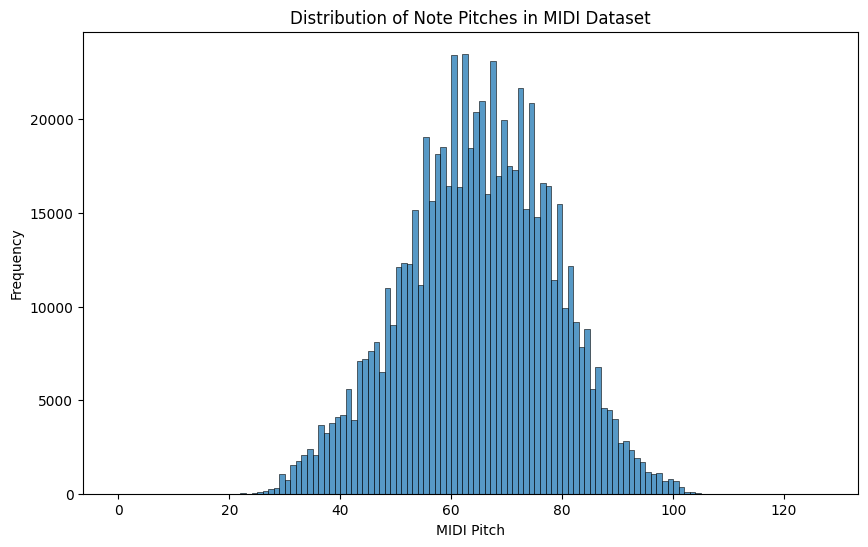

In [27]:
# Create the distribution of features for training the model
# This step will depend on the specific model architecture and training requirements
# For example, you might want to create sequences of features for training a sequence model like an LSTM or Transformer.

import seaborn as sns
import matplotlib.pyplot as plt
# Example: Visualize the distribution of note pitches across all MIDI files
all_pitches = []
for features in midi_features:
    if features.size > 0:  # Check if there are features to avoid errors
        all_pitches.extend(features[:, 2])  # Extract the pitch column (index 2)
# Plot the distribution of note pitches using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(all_pitches, bins=range(0, 128), kde=False)
plt.title('Distribution of Note Pitches in MIDI Dataset')
plt.xlabel('MIDI Pitch')
plt.ylabel('Frequency')     

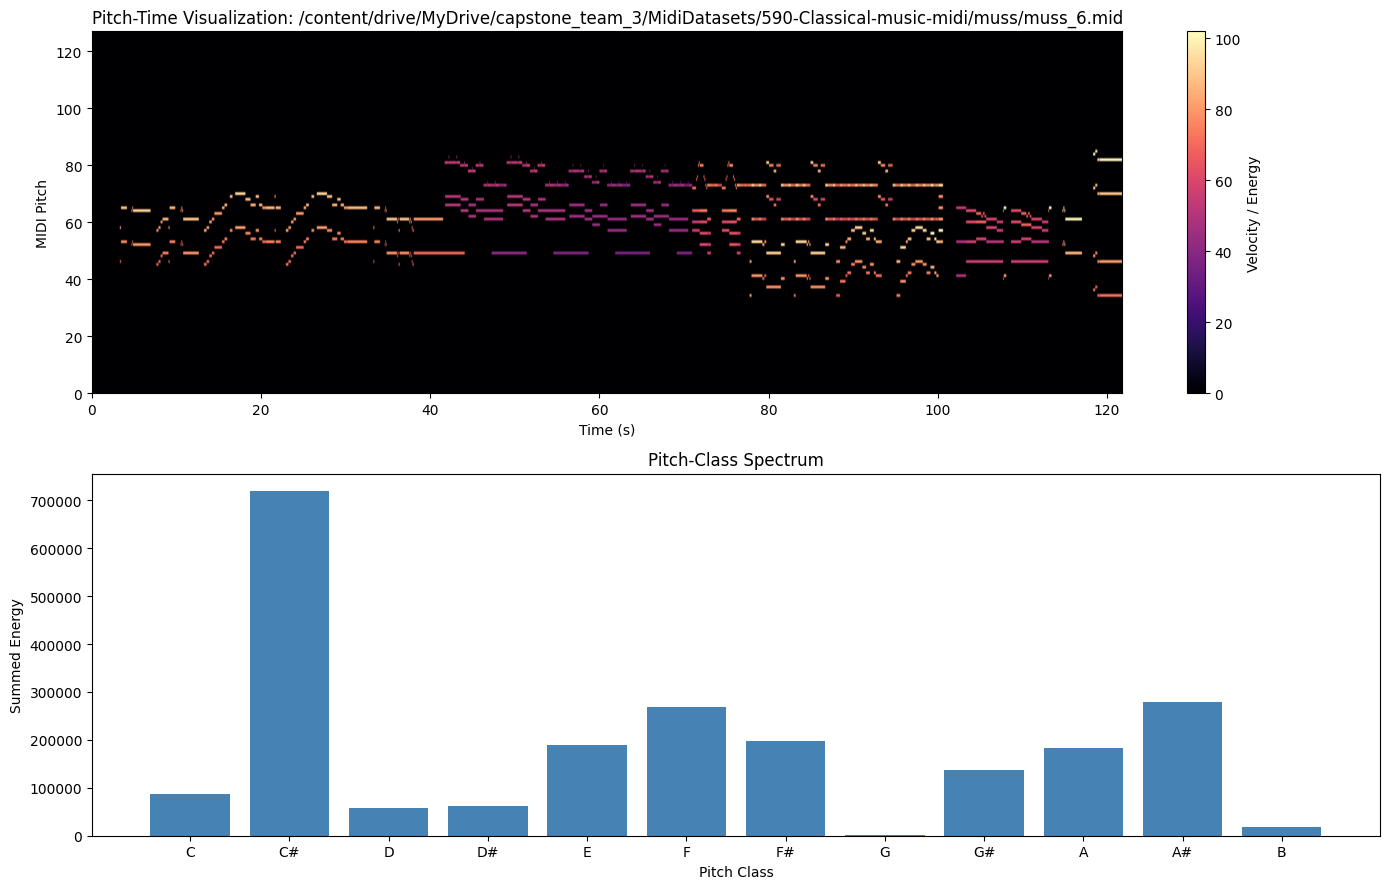

In [28]:
# Visualize one MIDI file by pitch over time and pitch-class spectrum
import numpy as np
import matplotlib.pyplot as plt

if not midi_files:
    print("No MIDI files available to visualize.")
else:
    # Pick a MIDI file (you can change index to inspect others)
    midi_idx = 0
    midi_path = midi_files[midi_idx]
    midi_data = pretty_midi.PrettyMIDI(midi_path)

    # Piano roll: rows=pitches (0-127), cols=time frames
    fs = 100  # frames per second
    piano_roll = midi_data.get_piano_roll(fs=fs)

    # Build a simple pitch-class spectrum (C..B) from total note energy
    chroma = np.zeros(12)
    if piano_roll.size > 0:
        for pitch in range(128):
            chroma[pitch % 12] += piano_roll[pitch].sum()

    # Time axis for piano roll
    time_axis = np.arange(piano_roll.shape[1]) / fs if piano_roll.size > 0 else np.array([0])

    fig, axes = plt.subplots(2, 1, figsize=(14, 9))

    # Plot 1: Pitch-time heatmap
    if piano_roll.size > 0:
        im = axes[0].imshow(
            piano_roll,
            origin='lower',
            aspect='auto',
            cmap='magma',
            extent=[time_axis.min(), time_axis.max(), 0, 127]
        )
        fig.colorbar(im, ax=axes[0], label='Velocity / Energy')
    axes[0].set_title(f'Pitch-Time Visualization: {midi_path}')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('MIDI Pitch')

    # Plot 2: Pitch-class spectrum
    note_names = ['C', 'C#', 'D', 'D#', 'E', 'F', 'F#', 'G', 'G#', 'A', 'A#', 'B']
    axes[1].bar(note_names, chroma, color='steelblue')
    axes[1].set_title('Pitch-Class Spectrum')
    axes[1].set_xlabel('Pitch Class')
    axes[1].set_ylabel('Summed Energy')

    plt.tight_layout()
    plt.show()

In [30]:
# Convert the pitch into  windowed sequences for training a sequence model
def create_sequences(features, sequence_length=50):
    sequences = []
    for i in range(len(features) - sequence_length):
        seq = features[i:i + sequence_length]
        sequences.append(seq)
    return np.array(sequences)

# Covvert the all the midi features into sequences for training,  Each sequence will be a window of 50 notes (or other features) for training a model like an LSTM or Transformer. Label the sequences appropriately for supervised learning, give the name of the midi file as the label for each sequence.
all_sequences = []
for midi_path, features in zip(midi_files, midi_features):
    if features.size > 0:  # Check if there are features to avoid errors
        sequences = create_sequences(features)
        labels = [midi_path] * len(sequences)  # Label each sequence with the MIDI file name
        all_sequences.extend(zip(sequences, labels))
print(f"Total sequences created: {len(all_sequences)}")

# Create a DF for the sequences and labels
sequences_df = pd.DataFrame(all_sequences, columns=['sequence', 'label'])
print(f"Shape of sequences DataFrame: {sequences_df.shape}")


Total sequences created: 690995
Shape of sequences DataFrame: (690995, 2)


In [61]:
# Shape of the each sequence
sequences_df['sequence'].head(1).values[0].shape

(50, 4)

In [62]:
sequences_df['sequence'].head(1).values[0]

array([[ 3.29680833,  3.42077533, 58.        , 80.        ],
       [ 3.42077533,  4.13083433, 65.        , 88.        ],
       [ 4.66337858,  4.75213596, 64.        , 80.        ],
       [ 4.75213596,  4.84089333, 65.        , 80.        ],
       [ 4.84089333,  6.92181933, 64.        , 92.        ],
       [ 7.61546133,  7.85788567, 57.        , 80.        ],
       [ 7.85788567,  8.10031   , 58.        , 80.        ],
       [ 8.10031   ,  8.34273433, 60.        , 80.        ],
       [ 8.34273433,  9.04780317, 61.        , 86.        ],
       [ 9.04780317,  9.17177017, 58.        , 80.        ],
       [ 9.17177017,  9.84216117, 65.        , 86.        ],
       [10.47735667, 10.57735667, 64.        , 80.        ],
       [10.57735667, 10.67735667, 65.        , 80.        ],
       [10.67735667, 10.77735667, 64.        , 80.        ],
       [10.77735667, 12.62351167, 61.        , 90.        ],
       [13.23889667, 13.54658917, 57.        , 82.        ],
       [13.54658917, 13.

In [ ]:
# Save the sequences as pickle file
sequences_df.to_pickle('/content/drive/MyDrive/capstone_team_3/midi_sequences.pkl')
print("MIDI sequences and labels saved to pickle file.")


In [31]:
# Sample a few sequences and labels to verify
print("Sample sequences and labels:")
print(sequences_df.head())  

Sample sequences and labels:
                                            sequence  \
0  [[3.296808333333334, 3.4207753333333337, 58.0,...   
1  [[3.4207753333333337, 4.1308343333333335, 65.0...   
2  [[4.663378583333333, 4.752135958333334, 64.0, ...   
3  [[4.752135958333334, 4.840893333333334, 65.0, ...   
4  [[4.840893333333334, 6.9218193333333335, 64.0,...   

                                               label  
0  /content/drive/MyDrive/capstone_team_3/MidiDat...  
1  /content/drive/MyDrive/capstone_team_3/MidiDat...  
2  /content/drive/MyDrive/capstone_team_3/MidiDat...  
3  /content/drive/MyDrive/capstone_team_3/MidiDat...  
4  /content/drive/MyDrive/capstone_team_3/MidiDat...  


In [32]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(sequences_df, test_size=0.2, random_state=42)
print(f"Training set size: {len(train_df)}")
print(f"Testing set size: {len(test_df)}")  

Training set size: 552796
Testing set size: 138199


In [34]:
# Baseline sequence-classification setup and similarity helpers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
import torch.optim as optim

def cosine_similarity(vec1, vec2):
    vec1 = np.asarray(vec1, dtype=np.float32)
    vec2 = np.asarray(vec2, dtype=np.float32)
    dot_product = np.dot(vec1, vec2)
    norm_vec1 = np.linalg.norm(vec1)
    norm_vec2 = np.linalg.norm(vec2)
    if norm_vec1 == 0 or norm_vec2 == 0:
        return 0.0
    return float(dot_product / (norm_vec1 * norm_vec2))

def features_to_vector(features):
    features = np.asarray(features, dtype=np.float32)
    if features.ndim == 1:
        features = features.reshape(1, -1)
    summary_vector = np.concatenate([
        features.mean(axis=0),
        features.std(axis=0),
        features.min(axis=0),
        features.max(axis=0)
    ])
    return summary_vector.astype(np.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


### Baseline LSTM sequence classifier
Prepare normalized sequence tensors, train a simple LSTM classifier, and compare learned embeddings with cosine similarity.

In [35]:
# Prepare normalized tensors and dataloaders
train_sequences = np.stack(train_df['sequence'].to_numpy()).astype(np.float32)
test_sequences = np.stack(test_df['sequence'].to_numpy()).astype(np.float32)

feature_mean = train_sequences.reshape(-1, train_sequences.shape[-1]).mean(axis=0)
feature_std = train_sequences.reshape(-1, train_sequences.shape[-1]).std(axis=0) + 1e-6

X_train = (train_sequences - feature_mean) / feature_std
X_test = (test_sequences - feature_mean) / feature_std

label_encoder = LabelEncoder()
label_encoder.fit(sequences_df['label'])
y_train = label_encoder.transform(train_df['label'])
y_test = label_encoder.transform(test_df['label'])

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

batch_size = 64
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=batch_size, shuffle=False)

input_dim = X_train.shape[-1]
sequence_length = X_train.shape[1]
num_classes = len(label_encoder.classes_)

print(f'Train tensor shape: {X_train_tensor.shape}')
print(f'Test tensor shape: {X_test_tensor.shape}')
print(f'Input dimension: {input_dim}, Sequence length: {sequence_length}, Classes: {num_classes}')

Train tensor shape: torch.Size([552796, 50, 4])
Test tensor shape: torch.Size([138199, 50, 4])
Input dimension: 4, Sequence length: 50, Classes: 292


In [36]:
# Define and train a baseline LSTM classifier
class LSTMSequenceClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes, num_layers=2, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, return_embedding=False):
        _, (hidden_state, _) = self.lstm(x)
        embedding = self.dropout(hidden_state[-1])
        logits = self.classifier(embedding)
        if return_embedding:
            return logits, embedding
        return logits

hidden_dim = 128
learning_rate = 1e-3
epochs = 5

model = LSTMSequenceClassifier(input_dim=input_dim, hidden_dim=hidden_dim, num_classes=num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        logits = model(batch_inputs)
        loss = criterion(logits, batch_labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * batch_inputs.size(0)
        train_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
        train_total += batch_labels.size(0)

    model.eval()
    test_loss = 0.0
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for batch_inputs, batch_labels in test_loader:
            batch_inputs = batch_inputs.to(device)
            batch_labels = batch_labels.to(device)

            logits = model(batch_inputs)
            loss = criterion(logits, batch_labels)

            test_loss += loss.item() * batch_inputs.size(0)
            test_correct += (logits.argmax(dim=1) == batch_labels).sum().item()
            test_total += batch_labels.size(0)

    epoch_metrics = {
        'epoch': epoch + 1,
        'train_loss': train_loss / train_total,
        'train_accuracy': train_correct / train_total,
        'test_loss': test_loss / test_total,
        'test_accuracy': test_correct / test_total
    }
    history.append(epoch_metrics)
    print(
        f"Epoch {epoch + 1}/{epochs} - "
        f"train_loss: {epoch_metrics['train_loss']:.4f}, "
        f"train_accuracy: {epoch_metrics['train_accuracy']:.4f}, "
        f"test_loss: {epoch_metrics['test_loss']:.4f}, "
        f"test_accuracy: {epoch_metrics['test_accuracy']:.4f}"
    )

history_df = pd.DataFrame(history)
history_df

Epoch 1/5 - train_loss: 4.2570, train_accuracy: 0.0830, test_loss: 3.5762, test_accuracy: 0.1638
Epoch 2/5 - train_loss: 3.2909, train_accuracy: 0.2133, test_loss: 2.4920, test_accuracy: 0.3789
Epoch 3/5 - train_loss: 2.4161, train_accuracy: 0.3856, test_loss: 1.6259, test_accuracy: 0.5863
Epoch 4/5 - train_loss: 1.7943, train_accuracy: 0.5233, test_loss: 1.0855, test_accuracy: 0.7207
Epoch 5/5 - train_loss: 1.4033, train_accuracy: 0.6152, test_loss: 0.7486, test_accuracy: 0.8080


,epoch,train_loss,train_accuracy,test_loss,test_accuracy
0,1,4.257037,0.082971,3.576202,0.163807
1,2,3.290894,0.213317,2.491950,0.378932
2,3,2.416068,0.385614,1.625865,0.586321
3,4,1.794285,0.523320,1.085478,0.720693
4,5,1.403298,0.615158,0.748578,0.808002


In [37]:
# Evaluate predictions and compare embeddings with cosine similarity
model.eval()
all_predictions = []
all_targets = []
train_embedding_sums = np.zeros((num_classes, hidden_dim), dtype=np.float32)
train_embedding_counts = np.zeros(num_classes, dtype=np.int32)

with torch.no_grad():
    for batch_inputs, batch_labels in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        _, embeddings = model(batch_inputs, return_embedding=True)
        embeddings = embeddings.cpu().numpy()
        labels_np = batch_labels.cpu().numpy()

        for embedding, label in zip(embeddings, labels_np):
            train_embedding_sums[label] += embedding
            train_embedding_counts[label] += 1

    for batch_inputs, batch_labels in test_loader:
        batch_inputs = batch_inputs.to(device)
        batch_labels = batch_labels.to(device)
        logits, _ = model(batch_inputs, return_embedding=True)
        predictions = logits.argmax(dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(batch_labels.cpu().numpy())

prototype_embeddings = train_embedding_sums / np.maximum(train_embedding_counts[:, None], 1)
test_accuracy = accuracy_score(all_targets, all_predictions)
print(f'Test accuracy: {test_accuracy:.4f}')

prediction_preview = pd.DataFrame({
    'true_label': label_encoder.inverse_transform(all_targets[:10]),
    'predicted_label': label_encoder.inverse_transform(all_predictions[:10])
})
prediction_preview

sample_index = 0
sample_sequence = X_test_tensor[sample_index:sample_index + 1].to(device)
sample_true_label = label_encoder.inverse_transform([y_test[sample_index]])[0]

with torch.no_grad():
    sample_logits, sample_embedding = model(sample_sequence, return_embedding=True)
    sample_prediction = int(sample_logits.argmax(dim=1).item())
    sample_embedding = sample_embedding.squeeze(0).cpu().numpy()

similarity_rows = []
for class_index, class_name in enumerate(label_encoder.classes_):
    similarity_rows.append({
        'label': class_name,
        'cosine_similarity': cosine_similarity(sample_embedding, prototype_embeddings[class_index])
    })

similarity_df = pd.DataFrame(similarity_rows).sort_values('cosine_similarity', ascending=False).head(5)
print(f'Sample true label: {sample_true_label}')
print(f"Sample predicted label: {label_encoder.inverse_transform([sample_prediction])[0]}")
similarity_df

Test accuracy: 0.8080
Sample true label: /content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi/schubert/schuim-4.mid
Sample predicted label: /content/drive/MyDrive/capstone_team_3/MidiDatasets/590-Classical-music-midi/schubert/schuim-4.mid


,label,cosine_similarity
69,/content/drive/MyDrive/capstone_team_3/MidiDat...,0.506712
22,/content/drive/MyDrive/capstone_team_3/MidiDat...,0.494526
245,/content/drive/MyDrive/capstone_team_3/MidiDat...,0.488723
249,/content/drive/MyDrive/capstone_team_3/MidiDat...,0.488270
254,/content/drive/MyDrive/capstone_team_3/MidiDat...,0.468650


In [42]:
# Create test midi sequences  for midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs")
test_sequences = []
test_midi_directory = Path("/content/drive/MyDrive/capstone_team_3/MidiDatasets/TestingSamples/MidiOutputs")
test_files=[]
for root, dirs, files in os.walk(test_midi_directory):
    for file in files:
        if file.endswith('.mid') or file.endswith('.midi'):
            midi_path = os.path.join(root, file)
            midi_data = pretty_midi.PrettyMIDI(midi_path)
            features = extract_features(midi_data)
            test_sequences.append((features, file))  # Store features and filename as label
print(f"Total test MIDI sequences created: {len(test_sequences)}")




/usr/local/lib/python3.12/dist-packages/pretty_midi/pretty_midi.py:122: RuntimeWarning: Tempo, Key or Time signature change events found on non-zero tracks.  This is not a valid type 0 or type 1 MIDI file.  Tempo, Key or Time Signature may be wrong.
  warnings.warn(


Total test MIDI sequences created: 50


In [43]:
# merge the test sequences ,filename and features into a single list for evaluation
merged_test_sequences = []
# Store each sequence with the MIDI file name as label
for features, filename in test_sequences:
    if features.size > 0:
        sequences = create_sequences(features)
        for seq in sequences:
            merged_test_sequences.append((seq, filename))  # Store each sequence with the MIDI file name as label

In [44]:
# Create a DATAFRAME for the merged test sequences
test_df = pd.DataFrame(merged_test_sequences, columns=['sequence', 'label'])
print(f"Shape of merged test sequences DataFrame: {test_df.shape}")
print("Sample merged test sequences:")
print(test_df.head())

Shape of merged test sequences DataFrame: (212275, 2)
Sample merged test sequences:
                                            sequence  \
0  [[1.5, 2.3, 65.0, 44.0], [2.3, 2.6, 69.0, 47.0...   
1  [[2.3, 2.6, 69.0, 47.0], [2.7, 3.5, 72.0, 49.0...   
2  [[2.7, 3.5, 72.0, 49.0], [3.5, 3.8041666666666...   
3  [[3.5, 3.8041666666666667, 69.0, 52.0], [3.900...   
4  [[3.9000000000000004, 4.7, 70.0, 54.0], [4.7, ...   

                       label  
0  Piano Sonata n12 K332.mid  
1  Piano Sonata n12 K332.mid  
2  Piano Sonata n12 K332.mid  
3  Piano Sonata n12 K332.mid  
4  Piano Sonata n12 K332.mid  


In [ ]:
test_df

,sequence,label,predicted_label
0,"[[1.5, 2.3, 65.0, 44.0], [2.3, 2.6, 69.0, 47.0...",Piano Sonata n12 K332.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
1,"[[2.3, 2.6, 69.0, 47.0], [2.7, 3.5, 72.0, 49.0...",Piano Sonata n12 K332.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
2,"[[2.7, 3.5, 72.0, 49.0], [3.5, 3.8041666666666...",Piano Sonata n12 K332.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
3,"[[3.5, 3.8041666666666667, 69.0, 52.0], [3.900...",Piano Sonata n12 K332.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
4,"[[3.9000000000000004, 4.7, 70.0, 54.0], [4.7, ...",Piano Sonata n12 K332.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
...,...,...,...
212270,"[[2481.236625562502, 2481.294317812502, 51.0, ...",Piano Sonata n29 Op106 ''Hammerklavier''.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
212271,"[[2481.294317812502, 2481.352010062502, 50.0, ...",Piano Sonata n29 Op106 ''Hammerklavier''.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
212272,"[[2481.352010062502, 2481.438548437502, 48.0, ...",Piano Sonata n29 Op106 ''Hammerklavier''.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...
212273,"[[2481.438548437502, 2481.5250868125017, 50.0,...",Piano Sonata n29 Op106 ''Hammerklavier''.mid,/content/drive/MyDrive/capstone_team_3/MidiDat...


In [47]:
# Convert merged_test_sequences to X_test and run inference
X_test_sequences = np.stack(test_df['sequence'].to_numpy()).astype(np.float32)
X_test = (X_test_sequences - feature_mean) / feature_std

# Predict label for each test sequence using cosine similarity to class prototypes
model.eval()
predicted_labels = []
with torch.no_grad():
    for seq in X_test:
        seq_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
        _, seq_embedding = model(seq_tensor, return_embedding=True)
        seq_embedding = seq_embedding.squeeze(0).cpu().numpy()

        similarities = [
            cosine_similarity(seq_embedding, prototype_embeddings[i])
            for i in range(num_classes)
        ]
        predicted_label_index = int(np.argmax(similarities))
        predicted_labels.append(label_encoder.inverse_transform([predicted_label_index])[0])

test_df['predicted_label'] = predicted_labels
print("Sample test sequences with predicted labels:")
print(test_df.head())

Sample test sequences with predicted labels:
                                            sequence  \
0  [[1.5, 2.3, 65.0, 44.0], [2.3, 2.6, 69.0, 47.0...   
1  [[2.3, 2.6, 69.0, 47.0], [2.7, 3.5, 72.0, 49.0...   
2  [[2.7, 3.5, 72.0, 49.0], [3.5, 3.8041666666666...   
3  [[3.5, 3.8041666666666667, 69.0, 52.0], [3.900...   
4  [[3.9000000000000004, 4.7, 70.0, 54.0], [4.7, ...   

                       label  \
0  Piano Sonata n12 K332.mid   
1  Piano Sonata n12 K332.mid   
2  Piano Sonata n12 K332.mid   
3  Piano Sonata n12 K332.mid   
4  Piano Sonata n12 K332.mid   

                                     predicted_label  
0  /content/drive/MyDrive/capstone_team_3/MidiDat...  
1  /content/drive/MyDrive/capstone_team_3/MidiDat...  
2  /content/drive/MyDrive/capstone_team_3/MidiDat...  
3  /content/drive/MyDrive/capstone_team_3/MidiDat...  
4  /content/drive/MyDrive/capstone_team_3/MidiDat...  


In [49]:
# Store test_df with predicted labels to CSV for analysis
test_df.to_csv('/content/drive/MyDrive/capstone_team_3/test_sequences_with_predictions.csv', index=False)
print("Test sequences with predicted labels saved to CSV file.")    

Test sequences with predicted labels saved to CSV file.


In [ ]:
test_df[['sequence', 'predicted_label']].head(1).values

array([[array([[ 1.5       ,  2.3       , 65.        , 44.        ],
               [ 2.3       ,  2.6       , 69.        , 47.        ],
               [ 2.7       ,  3.5       , 72.        , 49.        ],
               [ 3.5       ,  3.80416667, 69.        , 52.        ],
               [ 3.9       ,  4.7       , 70.        , 54.        ],
               [ 4.7       ,  5.        , 79.        , 58.        ],
               [ 5.10033563,  5.30167813, 77.        , 63.        ],
               [ 5.30167813,  5.46107427, 76.        , 59.        ],
               [ 5.50302063,  5.80922901, 76.        , 52.        ],
               [ 6.32706097,  6.72974597, 77.        , 53.        ],
               [ 6.72974597,  7.13243097, 69.        , 51.        ],
               [ 7.13243097,  7.43863935, 74.        , 48.        ],
               [ 7.53557247,  7.93825747, 67.        , 52.        ],
               [ 7.93825747,  8.55067791, 72.        , 57.        ],
               [ 8.55067791,  8.71

In [55]:
# shape of the sequence 
test_df[['sequence']].head(1).values[0][0].shape

(50, 4)